# PREPROCESSING

In [ ]:
# Init pack

import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats import linregress
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
import matplotlib.pyplot as plt
from torch.amp import GradScaler, autocast
import datetime
import shutil

psi = np.load('/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy')
psi = psi[:,1,:]

# Normalization
mean_psi = np.mean(psi, axis=0, keepdims=True)
std_psi = np.std(psi, axis=0, keepdims=True)
psi = (psi - mean_psi) / std_psi

# Pre-processing
lead = 1
trainN = 250000
valN = 50000
index = 63

# Defining the variable ranges
variable_range = [(0,24), (25, 49), (50, 74), (0, 49), (0,74)]

# Select the variable: 0 for real perturbation, 1 for imaginary perturbation, 2 for zonal winds, ...
variable = 3
num_variables = variable_range[variable][1] - variable_range[variable][0] + 1

# Shuffle and map indices
np.random.seed(42)
valid_indices = np.arange(0, trainN - lead)
shuffled_indices = np.random.permutation(valid_indices)

# Now constrain the shuffled indices to the variable range
np_psi_train_input = psi[shuffled_indices, variable_range[variable][0]:variable_range[variable][1]+1]
np_psi_train_label = psi[shuffled_indices + lead, :]

psi_train_input = torch.tensor(np_psi_train_input)
psi_train_label = torch.tensor(np_psi_train_label)

np_psi_val_input = psi[trainN:trainN+valN, variable_range[variable][0]:variable_range[variable][1]+1]
np_psi_val_label = psi[trainN+lead:trainN+valN+lead, :]
psi_val_input = torch.tensor(np_psi_val_input)
psi_val_label =  torch.tensor(np_psi_val_label)

plt.plot(np_psi_val_input[:,-1]) # Real and Imaginary PSI
plt.plot(np_psi_val_label[:,-1]) # Real and Imaginary PSI + Zonal Wind
plt.show()

In [10]:
# Define the encoder (MLP)
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(75, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 1024)
        self.fc4 = nn.Linear(1024, 1024)
        self.fc5 = nn.Linear(1024, 1024)
        self.fc6 = nn.Linear(1024, 1024)
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # Activation function for hidden layer
        x = torch.relu(self.fc2(x)) + x
        x = torch.relu(self.fc3(x)) + x
        x = torch.relu(self.fc4(x)) + x
        x = torch.relu(self.fc5(x)) + x
        x = torch.relu(self.fc6(x)) + x
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

# Define the decoder (MLP)
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim + condition_dim, 1024)
        self.fc2 = nn.Linear(1024, 1024) 
        self.fc3 = nn.Linear(1024, 1024)
        self.fc4 = nn.Linear(1024, 1024)
        self.fc5 = nn.Linear(1024, 1024)
        self.fc6 = nn.Linear(1024, 1024)
        self.fc_output = nn.Linear(1024, output_dim)

    def forward(self, z, condition):
        z = torch.cat((z, condition), dim=1)  # Concatenate latent vector and condition
        z = torch.relu(self.fc1(z))
        z = torch.relu(self.fc2(z)) + z
        z = torch.relu(self.fc3(z)) + z
        z = torch.relu(self.fc4(z)) + z
        z = torch.relu(self.fc5(z)) + z
        z = torch.relu(self.fc6(z)) + z
        output = self.fc_output(z)
        return output

# Define the VAE model
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim, output_dim, condition_dim):
        super(ConditionalVAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim, output_dim, condition_dim)

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z, condition):
        return self.decoder(z, condition)

    def forward(self, x, condition):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z, condition)
        return output, mu, logvar

output_dim = 75
latent_dim = 32
condition_dim = num_variables
batch_size = 1024

# CHOOSING BY EXP FIT

In [ ]:
def normalize_transition_time(s, dlt, r):
    """
    Normalize the transition time based on the specified delta and reference value.

    Args:
        s (float): The transition time to normalize.
        dlt (float): The delta value for normalization.
        r (float): The reference value for normalization.

    Returns:
        norm (float): The normalized transition time.
    """
    norm = 1 - np.exp(-np.abs((s - r)) / dlt)
    return norm

def calculate_transition_durations(y, u, l):
    """
    Calculate the return periods with user-defined upper and lower bounds.

    Args:
        y (np.array): The time series data.
        u (float): The upper bound for the transition.
        l (float): The lower bound for the transition.

    Returns:
        t_times (list): The list of return periods for transitions.
    """
    t_times = []
    s = None
    above_u = False
    below_l = False
    for i in range(1, len(y)):
        
        if y[i] < l:
            if above_u and s is not None:
                t_times.append(i-s)  
            below_l = True
            above_u = False

        elif y[i] > u:  
            if below_l and s is not None:
                t_times.append(i - s)
                s = None  
            above_u = True
            below_l = False

        if below_l and s is None:
            s = i

        if above_u and s is None:
            s = i
    return t_times

def KL_coefficient(r, p, delta, cycle, KL_by_dim_cycle):
    """
    Calculate the KL divergence between two distributions and normalize it.

    Args:
        r (np.array): Real distribution.
        p (np.array): Predicted distribution.
        delta (float): Delta value for normalization.
        cycle (int): Cycle number for tracking.
        KL_by_dim_cycle (dict): Dictionary to store KL divergence values by dimension and cycle.

    Returns:
        r (np.array): Processed real distribution.
        p (np.array): Processed predicted distribution.
        nkl (float): Normalized KL divergence.
    """
    # Calculating KL divergence
    r = r[:30000, 1, 63]
    p = p[:30000]
    
    rh, b = np.histogram(r, bins=50, density=True)
    ph, _ = np.histogram(p, bins=b, density=True)

    e = 1e-10
    rh += e
    ph += e

    # Calculate KL divergence between the two histograms
    kl = np.sum(rh * np.log(rh / ph))
    nkl = normalize_transition_time(kl, 1, 0)

    print(f"Normalized KL divergence for delta {delta}, cycle {cycle}: {nkl:.6f}")
    KL_by_dim_cycle[delta][cycle].append(nkl)

    return r, p, nkl

def Mean_and_std_of_predictions(p_times, r_times, dlt, cc, transitions_by_dim_cycle, transitions_normalized_by_dim_cycle, transitions_normalized_std_by_dim_cycle):
    """
    Calculate the mean and standard deviation of transition times from predictions and normalize them.

    Args:
        p_times (list): Transition times from predictions.
        r_times (list): Transition times from real data.
        dlt (float): Delta value for normalization.
        cc (int): Cycle number for tracking.
        transitions_by_dim_cycle (dict): Dictionary to store transition times by dimension and cycle.
        transitions_normalized_by_dim_cycle (dict): Dictionary to store normalized transition times by dimension and cycle.
        transitions_normalized_std_by_dim_cycle (dict): Dictionary to store normalized standard deviations by dimension and cycle.

    Returns:
        npd_mean (float): Normalized mean of transition times.
        npd_std (float): Normalized standard deviation of transition times.
    """
    p_mean = np.mean(p_times)
    p_std = np.std(p_times)

    pd_mean = abs(p_mean - np.mean(r_times))
    pd_std = abs(p_std - np.std(r_times))

    npd_mean = normalize_transition_time(pd_mean, 1000, np.mean(r_times))
    npd_std = normalize_transition_time(pd_std, 1000, np.std(r_times))

    npd_std = 1 if npd_std == 0 else npd_std

    transitions_by_dim_cycle[dlt][cc].append(pd_mean)
    transitions_normalized_by_dim_cycle[dlt][cc].append(npd_mean)
    transitions_normalized_std_by_dim_cycle[dlt][cc].append(npd_std)

    return npd_mean, npd_std

# KL Annealing (Fu et al., 2019)
def frange_cycle_linear(start, stop, n_epoch, n_cycle=4, ratio=0.5):
    """
    Generate a linear schedule for KL annealing over multiple cycles.

    Args:
        start (float): Starting value of the schedule.
        stop (float): Stopping value of the schedule.
        n_epoch (int): Total number of epochs.
        n_cycle (int): Number of cycles for the schedule.
        ratio (float): Ratio of the cycle length to the total number of epochs.

    Returns:
        L (np.array): Array containing the linear schedule values for each epoch.
    """
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # linear schedule

    for c in range(n_cycle):

        v , i = start , 0
        while v <=stop and (int(i+c*period) < n_epoch):
            L[int(i+c*period)] = v
            v += step
            i += 1
    return L

In [12]:
from matplotlib import gridspec
import seaborn as sns
import os

def Timeseries_plot(y, p, ep, ax):
    """
    Plot the timeseries.

    Args:
        y (np.array): Actual zonal wind values.
        p (np.array): Predicted zonal wind values.
        ep (int): Current epoch number.
        ax (matplotlib.axes.Axes): Axes object to plot on.

    Returns:
        None. Just plots the timeseries on the provided axes.
    """
    ax.plot(y, 'b', label='Actual')
    ax.plot(p, 'r', label='Predictions')

    ax.set_title(f"Timeseries | Epoch {ep}", fontsize=16)
    ax.set_xlabel('Time Step', fontsize=14)
    ax.set_ylabel('Zonal Wind Value', fontsize=14)

    ax.legend(['Predictions', 'Actual'])
    ax.grid(True)

def PDF_plot(y, p, ep, pdf_dt, ax):
    """
    Plot PDFs of the zonal wind values.

    Args:
        y (np.array): Actual zonal wind values.
        p (np.array): Predicted zonal wind values.
        ep (int): Current epoch number.
        pdf_dt (float): KL divergence between the PDFs of actual and predicted values.
        ax (matplotlib.axes.Axes): Axes object to plot on.

    Returns:
        None. Just plots the PDFs on the provided axes.
    """

    sns.histplot(y, bins=50, kde=True, color='black', alpha=0.6, element='step', label='Real Data', ax=ax)
    sns.histplot(p, bins=50, kde=True, color='red', alpha=0.6, element='step', label='Predictions', ax=ax)

    ax.set_title(f"Probability Distribution Functions (PDFs) | Epoch {ep} | KL Error: {pdf_dt:.4f}", fontsize=16)
    ax.set_xlabel('Zonal Wind (m/s)', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    
    ax.axvline(np.mean(y), color='black', linestyle='--', label=f'Real Mean: {np.mean(y):.2f}')
    ax.axvline(np.mean(p), color='red', linestyle='--', label=f'Pred Mean: {np.mean(p):.2f}')

    ax.legend(fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

def Exp_fit_plot(xlp, yvp, xlr, yvr, p_exp_fit, r_exp_fit, ep, exp_d, range_d, ax):
    """
    Plot the exponential fits of transition return periods.

    Args:
        xlp (np.array): X values for predicted exponential fit.
        yvp (np.array): Y values for predicted exponential fit.
        xlr (np.array): X values for real exponential fit.
        yvr (np.array): Y values for real exponential fit.
        p_exp_fit (float): Slope of the predicted exponential fit.
        r_exp_fit (float): Slope of the real exponential fit.
        ep (int): Current epoch number.
        exp_d (float): Exponential fit error for predictions.
        range_d (float): Range error for predictions.
        ax (matplotlib.axes.Axes): Axes object to plot on.

    Returns:
        None. Just plots the exponential fits on the provided axes.
    """
    ax.plot(xlp, yvp, 'r-', label=f'Pred Exp Fit (slope={p_exp_fit:.4f})', linewidth=2)
    ax.plot(xlr, yvr, 'b-', label=f'Real Exp Fit (slope={r_exp_fit:.4f})', linewidth=2)

    ax.set_xlabel('Time Duration (Steps)')
    ax.set_ylabel('Exponential Fit')
    ax.set_title(f"Exponential Fits of Transition Return Periods | Epoch {ep} | Exp Error: {exp_d:.4f} | Range Error: {range_d:.4f}", fontsize=16)
   
    ax.set_yscale("linear")
    ax.set_xscale("linear")
    
    ax.grid()
    ax.legend()
    
def Final_avg_transition_plot(transitions_by_dim_cycle, r, dlt, ncc, f):
    """
    Plot the average transition values across all cycles.

    Args:
        transitions_by_dim_cycle (dict): Dictionary containing transition values by dimension and cycle.
        r (float): Real data value for comparison.
        dlt (float): Delta coefficient for normalization.
        ncc (int): Number of cycles.
        f (str): Folder path to save the plot.
    
    Returns:
        None. Just plots the average transition values and saves the figure.
    """
    plt.figure(figsize=(10, 6))
    for c in range(ncc):
        plt.plot(transitions_by_dim_cycle[dlt][c], 'o-', label=f'Cycle {c}')
    
    plt.axhline(y=r, color='r', linestyle='--', label='Real Data')

    plt.xlabel('Epoch within Cycle')
    plt.ylabel('Average Transition Value')
    plt.ylim(0.1,2000)
    plt.title(f'Average Transition Progress (Delta Coefficient={dlt})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    f = os.path.join(f, f"transition_plot_all_cycles.png")
    plt.savefig(f)

    plt.show()

def Final_exp_fit_plot(exp_fit_by_dim_cycle, r_exp_fit, dlt, ncc, f):
    """
    Plot the exponential fit values across all cycles.

    Args:
        exp_fit_by_dim_cycle (dict): Dictionary containing exponential fit values by dimension and cycle.
        r_exp_fit (float): Real data value for comparison.
        dlt (float): Delta coefficient for normalization.
        ncc (int): Number of cycles.
        f (str): Folder path to save the plot.

    Returns:
        None. Just plots the exponential fit values and saves the figure.
    """
    plt.figure(figsize=(10, 6))
    for c in range(ncc):
        plt.plot(exp_fit_by_dim_cycle[dlt][c], 'o-', label=f'Cycle {c}')
    
    plt.axhline(y=r_exp_fit, color='r', linestyle='--', label='Real Data')

    plt.xlabel('Epoch within Cycle')
    plt.ylabel('Exponential Fit Value')
    plt.title(f'Exponential Fit Progress (Delta Coefficient={dlt})')
    plt.grid(True)
    plt.tight_layout()
    plt.legend()

    f = os.path.join(f, f"exponential_fit_plot_all_cycles.png")
    plt.savefig(f)
    
    plt.show()

def all_plot(y, p, xlp, yvp, xlr, yvr, 
             p_exp_fit, r_exp_fit, pdf_dt, exp_dt, range_dt, ep, folder):
    """
    Comprehensive plot with timeseries, PDF, and exponential fit.

    Args:
        y (np.array): Actual zonal wind values.
        p (np.array): Predicted zonal wind values.
        xlp (np.array): X values for predicted exponential fit.
        yvp (np.array): Y values for predicted exponential fit.
        xlr (np.array): X values for real exponential fit.
        yvr (np.array): Y values for real exponential fit.
        p_exp_fit (float): Slope of the predicted exponential fit.
        r_exp_fit (float): Slope of the real exponential fit.
        pdf_dt (float): KL divergence between the PDFs of actual and predicted values.
        exp_dt (float): Exponential fit error for predictions.
        range_dt (float): Range error for predictions.
        ep (int): Current epoch number.
        folder (str): Folder path to save the plot.
    
    Returns:
        None. Just plots the timeseries, PDF, and exponential fit and saves the figure.
    """
    fig = plt.figure(figsize=(24, 10))
    gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1,1], height_ratios=[1,1])

    ax_timmeseries = fig.add_subplot(gs[:, 0])
    ax_pdf = fig.add_subplot(gs[0, 1])
    ax_exp_fit = fig.add_subplot(gs[1, 1])

    Timeseries_plot(y, p, ep, ax_timmeseries)
    PDF_plot(y, p, ep, pdf_dt, ax_pdf)
    Exp_fit_plot(xlp, yvp, xlr, yvr, 
                 p_exp_fit, r_exp_fit, ep, exp_dt, range_dt, ax_exp_fit)
    
    dt = np.sqrt(pdf_dt**2 + exp_dt**2 + range_dt**2)
    fig.suptitle(f"Predictions vs Actual | Epoch {ep} | Euclidean Metric Error: {dt}", fontsize=20)
    plt.subplots_adjust(wspace=0.2, hspace=0.35)  # Adjust these values as desired
    fig.tight_layout(pad=2.0)
    plt.savefig(os.path.join(folder, f"plots/all_plots_epoch_{ep}.png"))
    plt.show()

def Loss_plot(t_loss, v_loss, cc, dlt, f):
    """
    Plot the training and validation losses.

    Args:
        t_loss (list): Training loss values.
        v_loss (list): Validation loss values.
        cc (int): Cycle number for tracking.
        dlt (float): Delta value for normalization.
        f (str): Folder path to save the plot.
    
    Returns:
        None. Just plots the training and validation losses and saves the figure.
    """
    plt.figure(figsize=(10,6))

    plt.plot(t_loss, label='Training Loss')
    plt.plot(v_loss, label='Validation Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Losses for Cycle {cc+1} with Delta {dlt}')
    plt.legend()

    f = os.path.join(f, f"loss_plot_cycle_{cc+1}_delta_{dlt}.png")
    plt.savefig(f)
    
    plt.show()

In [ ]:
beta_kl_coef = frange_cycle_linear(0.01, 0.3, 3, 1, 1)
print(beta_kl_coef)
num_epochs = 3

In [ ]:
# Training

torch.cuda.empty_cache()

def model_restore(mp, model):
    """
    Restore the model state from a saved checkpoint.

    Args:
        mp (str): Path to the model checkpoint.
        model (nn.Module): The model to restore.

    Returns:
        None. The model state is loaded from the checkpoint if it exists.
    """
    if os.path.exists(mp):
        print(f"Loading model from {mp}")
        model.load_state_dict(torch.load(mp))

def inference(model, psi, tst, vr, v, nv, ld):
    """
    Perform inference using the trained model.

    Args:
        model (nn.Module): The trained model.
        psi (np.array): Input data for inference.
        tst (int): Number of time steps.
        vr (dict): Variable ranges for the input data.
        v (int): Index of the variable to use for inference.
        nv (int): Number of variables.
        ld (int): Latent dimension of the model.
    
    Returns:
        p (np.array): Predictions made by the model.
    """
    s, e = vr[v][0], vr[v][1]+1
    init_c = torch.reshape(torch.tensor(psi[0,s:e]), [1, nv])
    z = torch.zeros([1,ld])
    p = np.zeros ([tst, 75])

    for k in range (0, tst):

        with torch.inference_mode():
            model.eval()

            with autocast(device_type='cuda'):

                if (k ==0):

                    z = torch.randn_like(z).float().cuda(non_blocking=True)
                    init_c = init_c.float().cuda(non_blocking=True)

                    y = (model.decode(z, init_c)).detach().cpu().numpy()
                    p[k,:] = y

                    init_c = torch.tensor(y[:, s:e])

                else:
                    z = torch.randn_like(z).float().cuda(non_blocking=True)
                    init_c = torch.reshape(torch.tensor(p[k-1,s:e]),[1,nv]).float().cuda(non_blocking=True)

                    y = (model.decode(z,init_c)).detach().cpu().numpy()
                    p[k,:] = y

                    init_c = torch.tensor(y[:, s:e])
    
    return p

def euclidean_distance_for_predictions(ms):
    """
    Calculate the Euclidean distance for a list of metrics.

    Args:
        ms (list): List of computed metrics.

    Returns:
        dt (float): The Euclidean distance calculated from the given computed metrics.
    """
    s = 0
    for m in ms:
        s += m ** 2
    dt = np.sqrt(s)
    return dt

def save_best_cycle_epoch(models, dlt, cc, ep, f,
                          exp_fit_normalized_by_dim_cycle, 
                          KL_by_dim_cycle, duration_diff_by_dim_cycle, 
                          best_models_saved, best_models):
    """
    Select the best model from a cycle based on combined distance metrics and save it.

    Args:
        models (list): List of model paths for the current cycle.
        dlt (float): Delta coefficient for normalization.
        cc (int): Current cycle number.
        ep (int): Current epoch number.
        f (str): Folder path to save the best model.
        exp_fit_normalized_by_dim_cycle (dict): Dictionary containing normalized exponential fit values by dimension and cycle.
        KL_by_dim_cycle (dict): Dictionary containing KL divergence values by dimension and cycle.
        duration_diff_by_dim_cycle (dict): Dictionary containing range differences by dimension and cycle.
        best_models_saved (list): List to store the paths of the best models saved.
        best_models (list): List to store the best models selected.

    Returns:
        None. The best model is saved to the specified folder.
    """
    
    b_model = None
    b_i = -1
    b_dt = float('inf')

    for i in range(len(models)):  # models contains each epoch's model in the current cycle
        print(exp_fit_normalized_by_dim_cycle[dlt][cc][i])
        print(KL_by_dim_cycle[dlt][cc][i])
        print(duration_diff_by_dim_cycle[dlt][cc][i])
        ms = [exp_fit_normalized_by_dim_cycle[dlt][cc][i],
                   KL_by_dim_cycle[dlt][cc][i], 
                   duration_diff_by_dim_cycle[dlt][cc][i]]
        
        dt = euclidean_distance_for_predictions(ms)
        if dt < b_dt:
            b_dt = dt
            shutil.copyfile(models[i], f"{f}/best_model_combined_distance_at_cycle_{cc}_and_checkpoint_{ep}.pth")
            print(f"New best model saved with distance {dt:.4f} at epoch {i+1}")
            b_i = i
            b_model = models[i]

    if b_i != -1:
        best_models_saved.append(b_model)
        best_models.append((cc, b_i))

def save_best_epoch(best_models, best_models_saved, exp_fit_normalized_by_dim_cycle,
                    KL_by_dim_cycle, duration_diff_by_dim_cycle, dlt, mf):
    
    """
    Select the best model from the master training run based on combined distance metrics and save it.

    Args:
        models (list): List of model paths for the current cycle.
        dlt (float): Delta coefficient for normalization.
        cc (int): Current cycle number.
        ep (int): Current epoch number.
        f (str): Folder path to save the best model.
        exp_fit_normalized_by_dim_cycle (dict): Dictionary containing normalized exponential fit values by dimension and cycle.
        KL_by_dim_cycle (dict): Dictionary containing KL divergence values by dimension and cycle.
        duration_diff_by_dim_cycle (dict): Dictionary containing range differences by dimension and cycle.
        best_models_saved (list): List to store the paths of the best models saved.
        best_models (list): List to store the best models selected.

    Returns:
        None. The best model is saved to the specified folder.
    """

    print("Selecting the best model based on combined distance...")

    # Ensure best_models is not empty
    if not best_models:
        print("No best models found.")
        return
    
    # After all cycles - final best model selection
    b_model = None
    w_model = (-1, -1)
    b_model_dt = float('inf')

    print(f"Number of best models saved: {len(best_models)}")
    for idx, (cc, ep_idx) in enumerate(best_models):

        ms = [exp_fit_normalized_by_dim_cycle[dlt][cc][ep_idx], 
                   KL_by_dim_cycle[dlt][cc][ep_idx], 
                   duration_diff_by_dim_cycle[dlt][cc][ep_idx]]
        
        dt = euclidean_distance_for_predictions(ms)        
        print(f"Distance for model from cycle {cc+1}, epoch {ep_idx+1}: {dt:.4f}")
        print(f"Current best distance: {b_model_dt:.4f}")
        
        if dt < b_model_dt:
            b_model_dt = dt
            b_model = best_models_saved[idx]
            w_model = (cc, ep_idx)

    # Save the best model  
    i,n = w_model
    cc = i
    ep = n

    if cc == -1:
        print("No best model found.")
    else:
        shutil.copyfile(b_model, f"{mf}/best_model_combined_distance_with_cycle_{cc+1}_and_epoch_{ep+1}.pth")
        print(f"Best model saved with cycle {cc+1} and epoch {ep+1}.")

# Initialization
scaler          = GradScaler()

latent_dims     = [1024]
latent_dim      = 32
kl_coefficients = [0.1]
kl_coef         = 0.1
delta_coefs     = [1]
time_step       = 30000
num_cycles      = 1
ens_size        = 1
level           = 63
upper_bound     = 53.8 / 2.8935
lower_bound     = 7.41

TRAIN_N         = 250000
VAL_N           = 50000

restore         = True

best_distance   = float('inf')

real_data       = np.load(r"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/data/actual/long_run_310k.npy")
real_data_1d    = real_data[:, 1, level]

# Function to calculate transition durations
real_durations      = calculate_transition_durations(real_data_1d, upper_bound, lower_bound)
real_data_sorted    = np.sort(real_durations)
transition_real     = np.mean(real_data_sorted)

actual_hist, bin_edges = np.histogram(real_data[:, 1, level], bins=50, density=True)
print(f"Reference Real Data average_transition_time: {transition_real}")

# Compute CCDF slope for real data
ccdf_real           = 1 - np.arange(1, len(real_data_sorted) + 1) / len(real_data_sorted)
valid_indices_real  = ccdf_real > 0
x_fit_real          = real_data_sorted[valid_indices_real]
y_fit_real          = np.log(ccdf_real[valid_indices_real])
slope_real, intercept_real, *_ = linregress(x_fit_real, y_fit_real)
print(f"Reference Real Data CCDF Slope: {slope_real}")

# Compute exponential fit for real data
x_line_real = np.linspace(min(real_data_sorted), max(real_data_sorted), 100)
exponential_fit_real = 1/np.mean(real_data_sorted)
y_values_real = exponential_fit_real*x_line_real

# Initialize dictionaries to store results
transitions_by_dim_cycle                = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}
transitions_normalized_by_dim_cycle     = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}
transitions_normalized_std_by_dim_cycle = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}
duration_diff_by_dim_cycle              = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}
exp_fit_by_dim_cycle                    = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}
exp_fit_normalized_by_dim_cycle         = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}
KL_by_dim_cycle                         = {dl: {cycle: [] for cycle in range(num_cycles)} for dl in delta_coefs}

models_by_dim_cycle = []
master_folder = f"/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/Resnet_VAE_model_DELTA_TEST_at_{datetime.datetime.now()}"
os.makedirs(master_folder)

for delta in delta_coefs:
    print(f"USING DELTA COEF OF {delta}")

    best_models         = []
    best_models_saved   = []

    losses_training     = []
    losses_validation   = []

    for cycle in range(0,num_cycles):

        models = []

        # Initialize the model, optimizer, and loss function
        model       = ConditionalVAE(latent_dim, output_dim, condition_dim)
        model       = model.cuda()
        optimizer   = optim.Adam(model.parameters(), lr=0.0001)

        # Create the folder structure for saving results
        subfolders  = ['plots','checkpoints']
        folder      = f"{master_folder}/model_at_{cycle}_with_delta_{delta}"
        os.makedirs(folder)
        for subfolder in subfolders:
            path = os.path.join(folder, subfolder)
            os.mkdir(path)

        # Restore the model if specified
        if restore:
            model_path = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/Resnet_VAE_model_DELTA_TEST_base_1000_epoch/model_at_0_with_delta_1/checkpoint_1000"
            model_restore(model_path, model)
        
        # Training loop
        for epoch in range(num_epochs):
            model.train()
            for batch in range (0, TRAIN_N, batch_size):
                
                input_batch = psi_train_input[batch:batch + batch_size,:]
                label_batch = psi_train_label[batch:batch + batch_size,:]

                optimizer.zero_grad()

                with autocast(device_type='cuda'):

                    outputs, mus, logvars = zip(*[model(label_batch.float().cuda(non_blocking=True), input_batch.float().cuda(non_blocking=True)) for _ in range(ens_size)])
                    output = torch.stack(outputs)
                    mu = torch.stack(mus)
                    logvar = torch.stack(logvars)

                    reconstruction_loss = F.smooth_l1_loss(output, label_batch.float().cuda(non_blocking=True), reduction="mean")
                    kl_loss = 0.5 * (mu ** 2 + torch.exp(logvar) - 1 - logvar).sum() * beta_kl_coef[epoch]

                    loss = reconstruction_loss + kl_loss
                    
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            losses_training.append(loss.item())
            print(f'''Epoch {epoch+1}, 
                Reconstrunction Loss: {reconstruction_loss.item()}
                KL Loss: {kl_loss.item()}
                Total Loss: {loss.item()}
                ''')

            # Validation Loss
            for batch in range (0, VAL_N, batch_size):

                model.eval()
                input_batch = psi_val_input[batch:batch + batch_size,:]
                label_batch = psi_val_label[batch:batch + batch_size,:]

                with torch.no_grad():
                    with autocast(device_type='cuda'):

                        outputs, mus, logvars = zip(*[model(label_batch.float().cuda(non_blocking=True), input_batch.float().cuda(non_blocking=True)) for _ in range(ens_size)])
                        output = torch.stack(outputs)
                        mu = torch.stack(mus)
                        logvar = torch.stack(logvars)

                        val_reconstruction_loss = F.smooth_l1_loss(output, label_batch.float().cuda(non_blocking=True), reduction="mean")
                        kl_loss = 0.5 * (mu ** 2 + torch.exp(logvar) - 1 - logvar).sum() * beta_kl_coef[epoch]  
                
                val_loss = val_reconstruction_loss + kl_loss

            losses_validation.append(val_loss.item())
            print(f'''
                Validation Reconstrunction Loss: {val_reconstruction_loss.item()}
                Validation KL Loss: {kl_loss.item()}
                Validation Total Loss: {val_loss.item()}''')
            
            # Inference
            pred = inference(model, psi, time_step, variable_range, variable, 
                             num_variables, latent_dim)

            # Denormalize final preds
            pred_mean = pred[:time_step, :] * std_psi[:, :] + mean_psi[:, :]
            actual_values = psi[:time_step, :] * std_psi[:, :] + mean_psi[:, :]
            predictions_1d = pred_mean[:, 63]  # shape (300000,)
            
            # Calculate transition durations for predictions
            pred_durations = calculate_transition_durations(predictions_1d, 
                                                            upper_bound, 
                                                            lower_bound)

            # Calculate KL coefficient
            KL_real_data, KL_predictions, avg_norm_KL = KL_coefficient(real_data, 
                                                                           predictions_1d, 
                                                                           delta, 
                                                                           cycle, 
                                                                           KL_by_dim_cycle)
            
            # Calculate mean and standard deviation of predictions
            transition_diff_normalized, transition_std_diff_normalized = Mean_and_std_of_predictions(pred_durations, 
                                                                                                     real_durations, 
                                                                                                     delta, cycle,
                                                                                                     transitions_by_dim_cycle,
                                                                                                     transitions_normalized_by_dim_cycle,
                                                                                                     transitions_normalized_std_by_dim_cycle)

            exponential_fit_pred = 0
            duration_diff_normalized = 1

            if len(pred_durations) > 0 and  len(np.unique(pred_durations)) > 1:

                # Calculate the exponential fit for predictions
                x_line_pred = np.linspace(min(pred_durations), max(pred_durations), 100)
                exponential_fit_pred = 1/np.mean(pred_durations)
                exp_fit_by_dim_cycle[delta][cycle].append(exponential_fit_pred)
                exp_fit_normalized = normalize_transition_time(exponential_fit_pred, 0.005, exponential_fit_real)
                exp_fit_normalized_by_dim_cycle[delta][cycle].append(exp_fit_normalized)
                print(f"Exponential Fit Normalized: {exp_fit_normalized:.6f}")

                # Calculate the y-values for the exponential fit
                y_values_pred = exponential_fit_pred*x_line_pred

                # Calculate the range of transitions
                max_pred = np.max(pred_durations)
                min_pred = np.min(pred_durations)
                
                if max_pred > 0:

                    # Calculate the predicted range and normalize it
                    difference = abs(max_pred - min_pred)
                    duration_diff_normalized = normalize_transition_time(difference, 10000, abs(np.max(real_durations)-np.min(real_durations)))
                    duration_diff_by_dim_cycle[delta][cycle].append(duration_diff_normalized)
                    print(f"Duration Difference Normalized: {duration_diff_normalized:.6f}")
                    all_plot(actual_values[:30000, 63],
                                predictions_1d[:30000], 
                                x_line_pred, y_values_pred, 
                                x_line_real, y_values_real, 
                                exponential_fit_pred, exponential_fit_real, avg_norm_KL,
                                exp_fit_normalized, duration_diff_normalized,
                                epoch+1, folder)
                    
                else:
                    print("No distribution of transitions detected in predictions.")
            else:
                exp_fit_by_dim_cycle[delta][cycle].append(exponential_fit_pred)
                duration_diff_by_dim_cycle[delta][cycle].append(duration_diff_normalized)
                exp_fit_normalized = normalize_transition_time(exponential_fit_pred, 0.005, exponential_fit_real)
                exp_fit_normalized_by_dim_cycle[delta][cycle].append(exp_fit_normalized)
                print("No transitions detected in predictions for exponential fit evaluation.")

            # Calculate accuracy by euclidean distance with specified metrics
            metrics = [exp_fit_normalized, avg_norm_KL, duration_diff_normalized]
            distance = euclidean_distance_for_predictions(metrics)
            print(f"Epoch {epoch+1}: Exponential Transition Fit Predictions Normalized: {exp_fit_normalized}, KL Normalized = {avg_norm_KL}, Duration Difference Normalized = {duration_diff_normalized}, Combined Distance = {distance:.6f}")
            
            # Save the model weights at each epoch
            path = f"{folder}/checkpoints/checkpoint_{epoch+1}"
            torch.save(model.state_dict(), path)
            print(f"Model weights saved to {folder} with point {epoch+1}.")
            models.append(path)

            # Final plots if last epoch
            if epoch == num_epochs - 1:

                folder = os.path.join(folder, "summary")
                if not os.path.exists(folder):
                    os.makedirs(folder)

                Final_avg_transition_plot(transitions_by_dim_cycle, transition_real, delta, num_cycles, folder)
                Final_exp_fit_plot(exp_fit_by_dim_cycle, exponential_fit_real, delta, num_cycles, folder)
        
        # Save the best model for the current cycle
        save_best_cycle_epoch(models, delta, cycle, epoch, folder, exp_fit_normalized_by_dim_cycle, 
                              KL_by_dim_cycle, duration_diff_by_dim_cycle,
                              best_models_saved, best_models)

        Loss_plot(losses_training, losses_validation, cycle, delta, folder)
# Save the best model after all cycles
save_best_epoch(best_models, best_models_saved, exp_fit_normalized_by_dim_cycle,
                KL_by_dim_cycle, duration_diff_by_dim_cycle, delta, master_folder)

# INFERENCE

/tmp/ipykernel_11735/1680021049.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path))


Model weights loaded from /home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/best_models_kinda/checkpoint_11.
(300000, 75) (309700, 75)
[[ 2.68805517  0.77174868 -1.14500578 ...  9.57838008 10.87889717
  12.24553601]
 [ 2.68358407  0.75713597 -1.17428308 ... 10.1707227  11.49106108
  12.87012698]
 [ 2.65586251  0.68419432 -1.30658217 ...  9.92322857 11.17768313
  12.51516709]
 ...
 [ 5.76696737  6.32096991  6.2352328  ... 36.84815553 38.08759189
  39.38471596]
 [ 5.81030593  6.45412426  6.41051561 ... 37.42387426 38.67235255
  39.97339147]
 [ 5.86828735  6.5747949   6.52648026 ... 37.75779178 38.97664868
  40.25776879]]


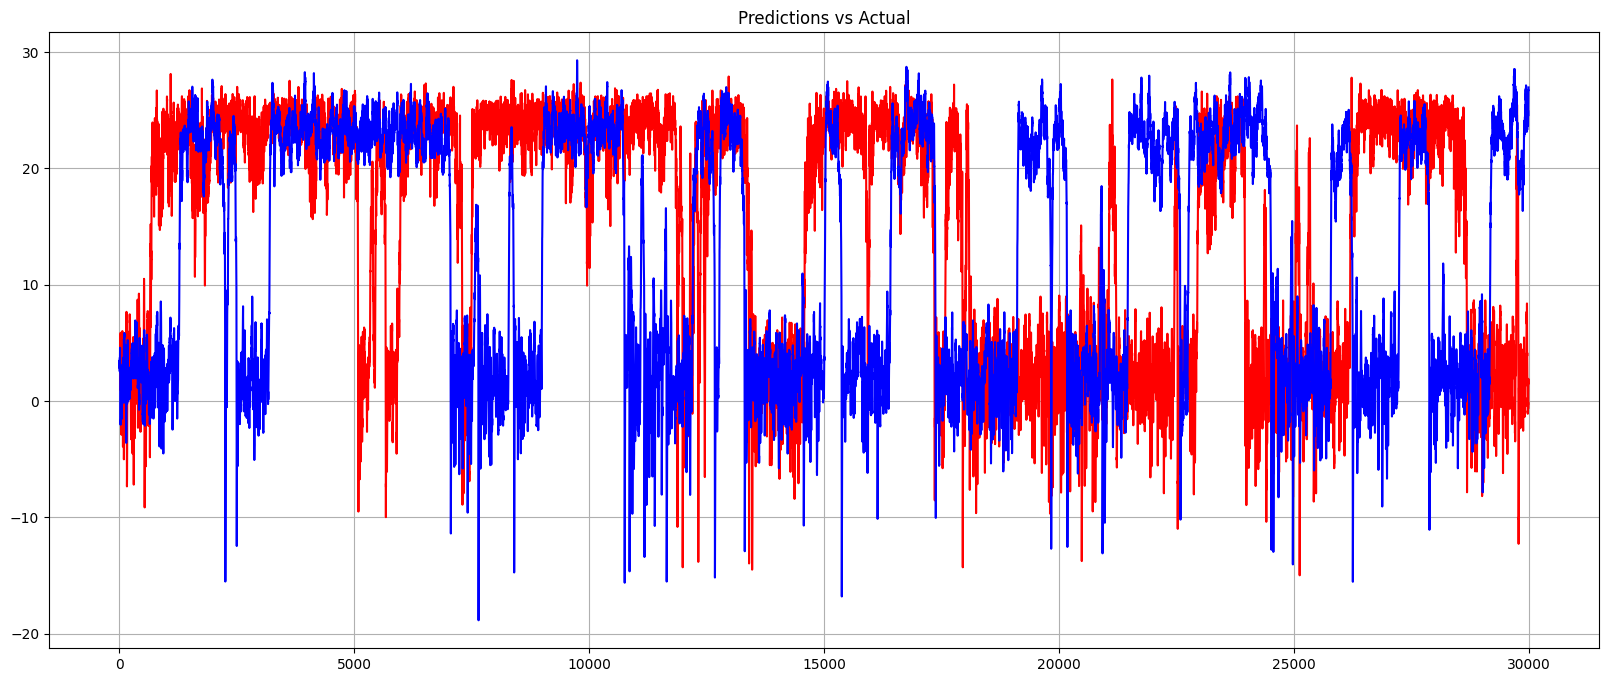

In [17]:
# Inference

# Initialize the model, optimizer, and loss function
latent_dim = 32
output_dim = 75
condition_dim = num_variables
model = ConditionalVAE(latent_dim, output_dim, condition_dim)
model = model.cuda()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
start, end = variable_range[variable][0], variable_range[variable][1]+1

# MODIFY THIS LINE FOR MODEL TESTING
past_model = True
if past_model:
    model_weights_path = "/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/best_models_kinda/checkpoint_11"
    if os.path.exists(model_weights_path):
        model.load_state_dict(torch.load(model_weights_path))
        print(f"Model weights loaded from {model_weights_path}.")

for _ in range (0,1):

    time_step = 30000
    pred_mean = inference(model, psi, time_step, variable_range, variable, num_variables, latent_dim)

    # Denormalize final preds
    pred = pred.reshape(pred.shape[0], pred.shape[1])
    print(pred.shape, psi.shape)
    pred_mean = pred[:time_step, :] * std_psi[:, :] + mean_psi[:, :]
    
    # Denormalize test labels
    actual_values = psi[:time_step, :] * std_psi[:, :] + mean_psi[:, :]
    print(actual_values)

    plt.figure(figsize=(20,8))
    plt.plot(pred_mean[0:time_step, 63],'r')
    plt.plot(actual_values[0:time_step, 63],'b')
    plt.grid(True)
    plt.title(f"Predictions vs Actual")
    plt.savefig(f'/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/prediction_vs_actual_{datetime.datetime.now()}.png')
    plt.show()

    np.save(f'/home/constantino-daniel-boscu/Documents/research/AI-RES/modified-code-main3/training_cycles/resnet/predictions_best_checkpoint_and_cycle_Resnet_VAE_temp.npy', pred_mean)